# Compare fitting-formula C(ℓ)

- Compare weak-lensing C(ℓ) derived from DarkEmulator2 and CLASS fitting-formula P(k).
- HALOFIT and HMcode provide P_total(k,z).
- All spectra are converted to C(ℓ) with the same Limber integration.

## Common settings

- `sample_params_for()` draws valid DE2 cosmologies.
- HMcode uses its calibration box.
- `pk_to_cl()` converts P(k,z) to C(ℓ) with the shared Limber setup.

In [1]:
import random
import time

import classy
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import InterpolatedUnivariateSpline as ius
from tqdm import tqdm

import dark_emulator2.derived as dv
from dark_emulator2 import DarkEmulator2

In [2]:
N_COSMO = 10
SEED = 1234

ZLIST = np.linspace(0.0, 1.0, 61)
RAW_KLIST = np.logspace(-3, 1, 301)
CL_KLIST = np.logspace(-2, 3, 401)
LLIST = np.logspace(1, 4, 101)

# None means a single source plane at ZLIST[-1].
SRC_DIST = None
PSHOT_FOR_EXTRAP = 0.3

CLASS_PK_MAX = 20.0
CLASS_Z_MAX = float(np.max(ZLIST) + 0.5)

In [3]:
def make_hmcode_range(version):
    version = str(version)
    if version == "2020":
        box = dict(
            omega_m=(0.120, 0.155),
            omega_b=(0.0215, 0.0235),
            Mnu=(0.0, 0.4),
            Omega_k=(-1e-4, 1e-4),
            ns=(0.85, 1.05),
            w0=(-1.3, -0.7),
            wa=(-1.3, 1.15),
            h0=(0.55, 0.85),
            sigma8=(0.494, 0.9),
        )
    else:
        raise ValueError("version must be '2020'")

    omega_m_box = box.pop("omega_m")
    box["Omega_m"] = (omega_m_box[0] / box["h0"][1]**2, omega_m_box[1] / box["h0"][0]**2)
    return box, omega_m_box


def valid_hmcode_box(p, omega_m_box):
    omega_m = p["Omega_m"] * p["h0"]**2
    return omega_m_box[0] <= omega_m <= omega_m_box[1]


def sample_params_for(range_dict=None, flags=None, valid=None, n=N_COSMO, seed=SEED, max_try=100000):
    random.seed(seed)
    np.random.seed(seed)
    emu = DarkEmulator2()
    if range_dict is None:
        range_dict = emu.param.get_preset_range_dict("preset_de2")
    if flags is None:
        flags = dict(nu=True, w0=True, wa=True, K=False)

    params = []
    ntry = 0
    with tqdm(total=n, desc="sample cosmologies") as pbar:
        while len(params) < n:
            ntry += 1
            if ntry > max_try:
                raise RuntimeError(f"Only collected {len(params)} cosmologies after {max_try} trials")

            p = emu.param.rand_param_cosmology(range_dict=range_dict, **flags)
            if not flags.get("nu", True):
                p["Mnu"] = 0.0
                p["Omega_nu"] = 0.0
            else:
                p["Omega_nu"] = p["Mnu"] / (93.14 * p["h0"]**2)

            if valid is not None and not valid(p, emu):
                continue

            emu.param.clear_As(p)
            emu.param.clear_lnAs(p)
            p["As"] = emu.get_As(p)
            p["dist"] = emu.get_power_distance(p)

            params.append(p)
            pbar.update(1)
            pbar.set_postfix(tries=ntry)

    return sorted(params, key=lambda q: q["dist"])


In [4]:
def run_de2_pk(params, zlist=ZLIST, klist=RAW_KLIST):
    emu = DarkEmulator2()
    pk_list = []
    for p in tqdm(params, desc="DE2 P(k)"):
        k, pk = emu.get_pk_total(p, zred=zlist, klist=klist, method="emulator")
        pk_list.append(pk)
    return k, np.asarray(pk_list)


def run_class_formula(params, zlist=ZLIST, klist=RAW_KLIST, formula="halofit", hmcode_version=None):
    pk_list = []
    desc = formula if hmcode_version is None else f"HMcode {hmcode_version}"

    for p in tqdm(params, desc=desc):
        cosmo = classy.Class()
        cosmo.set({
            "output": "mPk",
            "P_k_max_1/Mpc": CLASS_PK_MAX,
            "z_max_pk": CLASS_Z_MAX,
            "omega_b": p["omega_b"],
            "omega_cdm": p["omega_cdm"],
            "h": p["h0"],
            "A_s": p["As"],
            "n_s": p["ns"],
            "w0_fld": p["w0"],
            "wa_fld": p["wa"],
            "Omega_k": p["Omega_k"],
            "Omega_Lambda": 0.0,
            "cs2_fld": 1.0,
            "k_pivot": 0.05,
            "m_ncdm": p["Mnu"] / 3.0,
            "N_ncdm": 1,
            "deg_ncdm": 3,
            "N_ur": 0.00641,
            "T_cmb": 2.7255,
            "tau_reio": 0.079,
        })

        if formula == "halofit":
            cosmo.set({"non_linear": "halofit"})
        elif formula == "hmcode":
            cosmo.set({"non_linear": "HMcode", "hmcode_version": str(hmcode_version)})
        else:
            raise ValueError("formula must be 'halofit' or 'hmcode'")

        cosmo.compute()
        h = p["h0"]
        pk_z = []
        for z in zlist:
            pk_z.append([cosmo.pk(k * h, z) * h**3 for k in klist])
        pk_list.append(pk_z)
        cosmo.struct_cleanup()
        cosmo.empty()

    return klist, np.asarray(pk_list)

In [5]:
def extrap_pk_to_cl_grid(k, orig_k, pk, pshot=PSHOT_FOR_EXTRAP):
    scalar_input = False
    if pk.ndim == 1:
        pk = pk[np.newaxis]
        scalar_input = True

    pk = np.array([ius(np.log(orig_k), _pk)(np.log(k)) for _pk in pk])

    kmin, kmax = min(orig_k), max(orig_k)
    support_kmax = np.where(k < kmax)[0][-1]
    support_kmin = np.where(k > kmin)[0][0]

    cutoff_factor = 10
    logk = np.log10(k)
    logpk = np.log10(np.abs(pk))
    cutoff_pk = np.log10(cutoff_factor * pshot)
    pk_extrap = []
    for ilogpk in logpk:
        hits = np.flatnonzero(ilogpk[support_kmin:] < cutoff_pk)
        cutoff_idx = support_kmin + (hits[0] if hits.size else support_kmax)
        if k[cutoff_idx] > kmax:
            cutoff_idx = support_kmax
        pk_tmp = ius(logk[support_kmin:cutoff_idx], ilogpk[support_kmin:cutoff_idx], k=1)(logk)
        pk_extrap.append(10.0**pk_tmp)

    pk_extrap = np.array(pk_extrap)
    if scalar_input:
        pk_extrap = np.squeeze(pk_extrap)
    return pk_extrap


def pk_to_cl(params, k, pk, zlist=ZLIST, cl_klist=CL_KLIST, llist=LLIST, src_dist=SRC_DIST, label="P(k) -> C(ℓ)"):
    k = np.asarray(k)
    pk = np.asarray(pk)
    cls = []
    for i, (p, y) in enumerate(tqdm(list(zip(params, pk)), desc=label)):
        k_i = k if k.ndim == 1 else k[i]
        pk_i = extrap_pk_to_cl_grid(cl_klist, k_i, np.asarray(y))
        ell, cl = dv.pk2cl_limber_src_dist(
            p, pk=pk_i, klist=cl_klist, zlist=zlist,
            llist=llist, nsz=src_dist, modified=True,
        )
        cls.append(cl)
    return ell, np.asarray(cls)


def run_de2_cl(params):
    k, pk = run_de2_pk(params)
    ell, cl = pk_to_cl(params, k, pk, label="DE2 C(ℓ)")
    return k, pk, ell, cl

In [6]:
def plot_cl_comparison(result):
    params = result["params"]
    ell_de2 = np.asarray(result["ell_de2"])
    ell_fit = np.asarray(result["ell_fit"])
    cl_de2 = np.asarray(result["cl_de2"])
    cl_fit = np.asarray(result["cl_fit"])
    label = result["label"]

    colors = plt.cm.jet(np.linspace(0.05, 0.95, len(params)))
    fig, axes = plt.subplots(2, 1, figsize=(6.2, 6.2), sharex=True, height_ratios=[2, 1])
    ax0, ax1 = axes

    for i, color in enumerate(colors):
        ok_d = cl_de2[i] > 0
        ok_f = cl_fit[i] > 0
        de2_on_fit = np.exp(np.interp(np.log(ell_fit[ok_f]), np.log(ell_de2[ok_d]), np.log(cl_de2[i][ok_d])))

        ax0.loglog(ell_de2, ell_de2**2 * cl_de2[i] / (2.0 * np.pi), "--", color=color, lw=0.9, alpha=0.65)
        ax0.loglog(ell_fit[ok_f], ell_fit[ok_f]**2 * cl_fit[i][ok_f] / (2.0 * np.pi), "-", color=color, lw=0.9, alpha=0.75)
        ax1.semilogx(ell_fit[ok_f], cl_fit[i][ok_f] / de2_on_fit, "-", color=color, lw=0.9, alpha=0.8)

    ax0.plot([], [], "k--", label="DarkEmulator2")
    ax0.plot([], [], "k-", label=label)
    ax0.set_ylabel(r"$\ell^2 C_\ell / 2\pi$")
    ax0.legend(fontsize="large")
    ax0.grid(True, which="both", alpha=0.3)

    ax1.axhline(1.0, color="0.2", lw=0.8)
    ax1.axhline(0.95, color="0.4", lw=0.7, ls=":")
    ax1.axhline(1.05, color="0.4", lw=0.7, ls=":")
    ax1.set_ylim(0.75, 1.25)
    ax1.set_xlabel(r"$\ell$")
    ax1.set_ylabel(f"{label} / DE2")
    ax1.grid(True, which="both", alpha=0.3)

    fig.suptitle(rf"source plane $z_s={ZLIST[-1]:.1f}$")
    fig.tight_layout()
    plt.show()


## HALOFIT

In [7]:
halofit_params = sample_params_for(flags=dict(nu=True, w0=True, wa=True, K=False))
len(halofit_params)


sample cosmologies: 100%|█████████████████████████████████████████████████████| 10/10 [00:02<00:00,  4.77it/s, tries=10]


10

In [8]:
t0 = time.perf_counter()
k_de2, pk_de2, ell_de2, cl_de2 = run_de2_cl(halofit_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_halofit, pk_halofit = run_class_formula(halofit_params, formula="halofit")
ell_halofit, cl_halofit = pk_to_cl(halofit_params, k_halofit, pk_halofit, label="HALOFIT C(ℓ)")
halofit_time = time.perf_counter() - t0

halofit_result = dict(label="HALOFIT", params=halofit_params, ell_de2=ell_de2, cl_de2=cl_de2, ell_fit=ell_halofit, cl_fit=cl_halofit)
print(f"DE2:     {de2_time:.2f} sec")
print(f"HALOFIT: {halofit_time:.2f} sec")


HALOFIT C(ℓ): 100%|█████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 10.43it/s]

DE2:     7.68 sec
HALOFIT: 22.93 sec


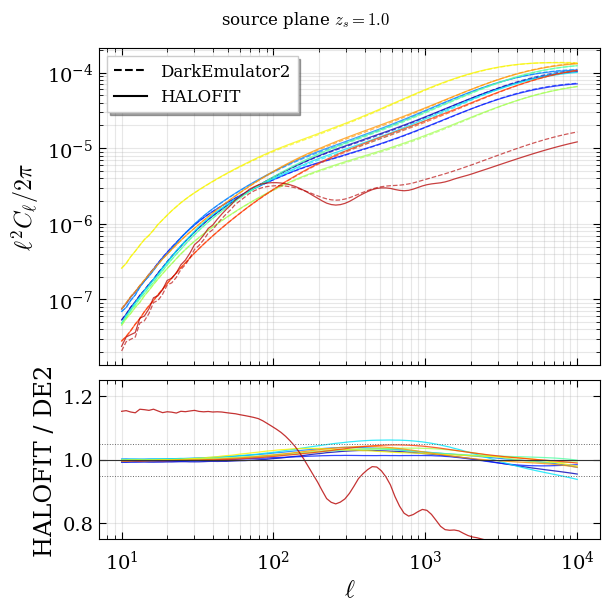

In [9]:
plot_cl_comparison(halofit_result)


## HMcode 2020

In [10]:
hmcode2020_range, hmcode2020_omega_m = make_hmcode_range("2020")
hmcode2020_params = sample_params_for(
    range_dict=hmcode2020_range,
    flags=dict(nu=True, w0=True, wa=True, K=False),
    valid=lambda p, emu: valid_hmcode_box(p, hmcode2020_omega_m),
)
len(hmcode2020_params)


sample cosmologies: 100%|█████████████████████████████████████████████████████| 10/10 [01:44<00:00, 10.41s/it, tries=47]


10

In [11]:
t0 = time.perf_counter()
k_de2, pk_de2, ell_de2, cl_de2 = run_de2_cl(hmcode2020_params)
de2_time = time.perf_counter() - t0

t0 = time.perf_counter()
k_hm2020, pk_hm2020 = run_class_formula(hmcode2020_params, formula="hmcode", hmcode_version="2020")
ell_hm2020, cl_hm2020 = pk_to_cl(hmcode2020_params, k_hm2020, pk_hm2020, label="HMcode 2020 C(ℓ)")
hm2020_time = time.perf_counter() - t0

hmcode2020_result = dict(label="HMcode 2020", params=hmcode2020_params, ell_de2=ell_de2, cl_de2=cl_de2, ell_fit=ell_hm2020, cl_fit=cl_hm2020)
print(f"DE2:         {de2_time:.2f} sec")
print(f"HMcode 2020: {hm2020_time:.2f} sec")


HMcode 2020 C(ℓ): 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.53it/s]

DE2:         5.75 sec
HMcode 2020: 44.80 sec


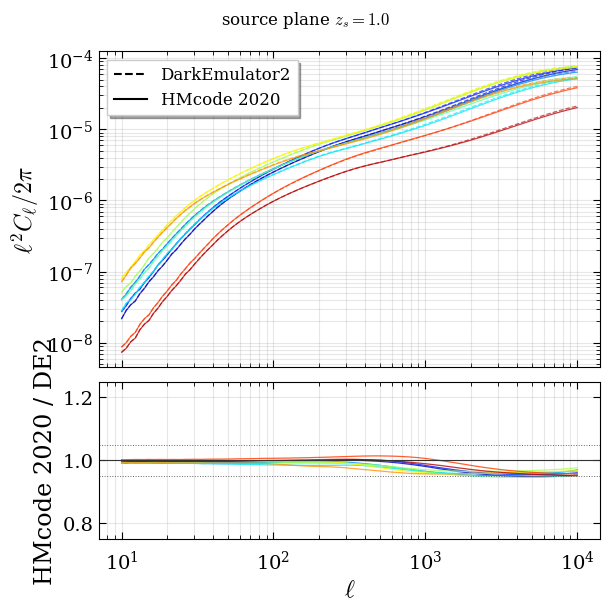

In [12]:
plot_cl_comparison(hmcode2020_result)
